# **Build a LLM From Scratch - Sebastian Raschka**

#### Verify PyTorch and CUDA

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import multiprocessing
import datasets
print(torch.__version__)
print(torch.cuda.is_available())
print(datasets.__version__)
multiprocessing.cpu_count()

2.11.0+cu128
True
3.6.0


12

#### Configuration

In [26]:
import os

torch.manual_seed(1009)

VOCAB_SIZE = 45098
CONTEXT_LEN = 256
EMB_DIM = 1024
N_HEADS = 16
N_LAYERS = 24
DROPOUT = 0.1
QKV_BIAS = False
TRAIN_RATIO = 0.9

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DTYPE = torch.bfloat16
CORES = 10
SAMPLE_BYTES = 10 * 1024 * 1024
TOKENIZER_BYTES = 30 * 1024 * 1024
PRETRAINING_GB = 1024 * 1024 * 1024
SAMPLE_FILE = "data/academic_sample.txt"
TOKENIZER_FILE = "data/academic_tokenizing.txt"
TOKENIZER_CONFIG = "data/tokenizer_config.txt"
PRETRAINING_FILE = "data/academic_pretraining.txt"
MODEL_FILE = "data/model.pth"
DATA = [TOKENIZER_FILE, TOKENIZER_BYTES]

#### Load and store data

In [3]:
os.environ["HF_TOKEN"] = ""

from datasets import load_dataset
print("Connecting to Hugging Face dataset stream...")
dataset = load_dataset(
    "allenai/peS2o", split="train", streaming=True, trust_remote_code=True
)

bytes_written = 0
line_count = 0
print(f"Writing to file {DATA[0]}...")

with open(DATA[0], "w", encoding="utf-8") as f:
    for r in dataset:
        raw = r.get("text", "").strip()

        if raw:
            text = " ".join(raw.splitlines())
            to_write = text + "\n"
            f.write(to_write)

            bytes_written += len(to_write.encode("utf-8"))
            line_count += 1

            if line_count % 15000 == 0:
                mb_written = bytes_written / (1024 * 1024)
                print(f"Written: {mb_written:.2f} MB ({line_count} documents)")

            if bytes_written >= DATA[1]:
                print("Max bytes reached. Disconnecting stream")
                break

print(f"Done.\nFile saved as {DATA[0]}, {bytes_written / (1024 * 1024):.2f} MB")

Connecting to Hugging Face dataset stream...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


Writing to file data/academic_tokenizing.txt...
Written: 19.00 MB (15000 documents)
Max bytes reached. Disconnecting stream
Done.
File saved as data/academic_tokenizing.txt, 30.00 MB


In [27]:
import pathlib


def load_tokenizer_data():
    if os.path.isfile(TOKENIZER_FILE):
        with open(TOKENIZER_FILE, "r", encoding="utf-8") as f:
            raw = f.readlines()
        return [l.rstrip() for l in raw]
    else:
        print(f"File {pathlib.Path(TOKENIZER_FILE).resolve()} not found")


def load_sample_data():
    if os.path.isfile(SAMPLE_FILE):
        with open(SAMPLE_FILE, "r", encoding="utf-8") as f:
            return f.readlines()
    else:
        print(f"File {pathlib.Path(SAMPLE_FILE).resolve()} not found")


def load_pretraining_data():
    if os.path.isfile(SAMPLE_FILE):
        with open(PRETRAINING_FILE, "r", encoding="utf-8") as f:
            raw = f.readlines()
        return [l.rstrip() for l in raw]
    else:
        print(f"File {pathlib.Path(SAMPLE_FILE).resolve()} not found")

## Tokenizer

In [41]:
from collections import defaultdict
from multiprocessing import Pool, cpu_count
from functools import lru_cache
import heapq
import ast, re

TOKENIZER_DATA = load_tokenizer_data()

pattern = re.compile(
    r'<\|endoftext\|>|<\|unk\|>|--|\s*[A-Za-z0-9]+|[\(\)\[\],._?!"\'—%&$€£-]'
)


def pre_tokenize(line):
    words = pattern.findall(line)
    return [w.replace(" ", "G̃") for w in words]


def _worker(lines):
    local = defaultdict(int)
    for line in lines:
        for w in pre_tokenize(line):
            local[w] += 1
    return local


def compute_word_freqs(data):
    print("Starting pre-tokenization...")

    chunk_size = (len(data) + CORES - 1) // CORES
    chunks_data = [data[i : i + chunk_size] for i in range(0, len(data), chunk_size)]

    with Pool(cpu_count()) as pool:
        results = pool.map(_worker, chunks_data)

    print("Chunks done")

    word_freqs = defaultdict(int)
    for r in results:
        for k, v in r.items():
            word_freqs[k] += v

    print("Pre-tokenization done")

    return word_freqs


def base_vocab(word_freqs):
    alphabet = []
    for w in word_freqs.keys():
        for l in w:
            if l not in alphabet:
                alphabet.append(l)
    alphabet.sort()
    print("Base vocabulary initialized, length:", len(alphabet) + 2)
    return ["<|endoftext|>", "<|unk|>"] + alphabet.copy()


def init_structures(word_freqs):
    splits = {w: list(w) for w in word_freqs}

    pair_freqs = defaultdict(int)
    pair_positions = defaultdict(set)

    for w, f in word_freqs.items():
        tokens = splits[w]

        for i in range(len(tokens) - 1):
            pair = (tokens[i], tokens[i + 1])
            pair_freqs[pair] += f
            pair_positions[pair].add((w, i))

    heap = [(-f, pair) for pair, f in pair_freqs.items()]
    heapq.heapify(heap)

    return splits, pair_freqs, pair_positions, heap


def merge(pair, splits, pair_freqs, pair_positions, heap, word_freqs):
    newi = "".join([*pair])
    affected = list(pair_positions[pair])
    pair_positions.pop(pair, None)

    for w, i in affected:
        tokens = splits[w]
        if i >= len(tokens) - 1 or tokens[i] != pair[0] or tokens[i + 1] != pair[1]:
            continue

        freq = word_freqs[w]

        if i > 0:
            l = (tokens[i - 1], tokens[i])
            pair_freqs[l] -= freq
            pair_positions[l].discard((w, i - 1))

        if i + 2 < len(tokens):
            r = (tokens[i + 1], tokens[i + 2])
            pair_freqs[r] -= freq
            pair_positions[r].discard((w, i + 1))

        tokens[i : i + 2] = [newi]

        if i > 0:
            lnew = (tokens[i - 1], newi)
            pair_freqs[lnew] += freq
            pair_positions[lnew].add((w, i - 1))
            heapq.heappush(heap, (-pair_freqs[lnew], lnew))

        if i < len(tokens) - 1:
            rnew = (newi, tokens[i + 1])
            pair_freqs[rnew] += freq
            pair_positions[rnew].add((w, i))
            heapq.heappush(heap, (-pair_freqs[rnew], rnew))


def create_vocab(data, vocab_size):
    word_freqs = compute_word_freqs(data)
    vocab = base_vocab(word_freqs)

    splits, pair_freqs, pair_positions, heap = init_structures(word_freqs)
    merges = {}

    while len(vocab) < vocab_size and heap:
        freq, pair = heapq.heappop(heap)
        freq = -freq

        if pair_freqs[pair] != freq or freq == 0:
            continue

        merge(pair, splits, pair_freqs, pair_positions, heap, word_freqs)

        newi = "".join([*pair])
        merges[pair] = newi
        vocab.append(newi)

        if len(vocab) % 1000 == 0:
            print("Vocab size:", len(vocab))

    token_to_id = {t: i for i, t in enumerate(vocab)}
    id_to_token = {i: t for t, i in token_to_id.items()}

    return token_to_id, id_to_token, vocab, merges


class BPETokenizer:
    def __init__(self, data=TOKENIZER_DATA, vocab_size=VOCAB_SIZE, new_vocab=False):
        if new_vocab:
            config = create_vocab(data, vocab_size)
        else:
            with open("data/tokenizer_config.txt", "r", encoding="utf-8") as f:
                config = ast.literal_eval(f.read())

        self.token_to_id, self.id_to_token, self.vocab, self.merges = config
        self.merge_ranks = {pair: i for i, pair in enumerate(self.merges)}

        if new_vocab and input("Save tokenizer configuration? [y/N]: ") == "y":
            settings = [self.token_to_id, self.id_to_token, self.vocab, self.merges]
            with open(TOKENIZER_CONFIG, "w", encoding="utf-8") as f:
                f.write(f"{settings}")

    def tokenize_word(self, word):
        tokens = list(word)
        if word in {"<|endoftext|>", "<|unk|>"} or len(tokens) <= 1:
            return [word]

        while True:
            best_rank = None
            best_idx = None

            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                rank = self.merge_ranks.get(pair)
                if rank is not None:
                    if best_rank is None or rank < best_rank:
                        best_rank = rank
                        best_idx = i

            if best_rank is None:
                break
            tokens[best_idx : best_idx + 2] = [tokens[best_idx] + tokens[best_idx + 1]]

        return tokens

    @lru_cache(maxsize=200_000)
    def tokenize_word_cached(self, word):
        return tuple(self.tokenize_word(word))

    def tokenize(self, text):
        words = pre_tokenize(text)
        tokens = []
        for w in words:
            tokens.extend(self.tokenize_word_cached(w))

        return list(tokens)

    def pad1d(self, tensors):
        maxi = max(t.shape[0] for t in tensors)

        if all(t.shape[0] == maxi for t in tensors):
            return tensors

        return [F.pad(t, (0, maxi - t.shape[0])) for t in tensors]

    def encode(self, *texts):
        if len(texts) == 0:
            raise TypeError(
                "At least 2 argument must be given to BPETokenizer.encode()"
            )

        tensors = [
            torch.tensor([self.token_to_id.get(t, 1) for t in self.tokenize(text)])
            for text in texts
        ]

        return tensors[0] if len(tensors) == 1 else self.pad1d(tensors)

    def decode(self, *tensors):
        if len(tensors) == 0:
            raise TypeError(
                "At least 2 argument must be given to BPETokenizer.decode()"
            )

        def to_ids(value):
            if isinstance(value, torch.Tensor):
                return value.detach().cpu().reshape(-1).tolist()

            if isinstance(value, (list, tuple)):
                if value and any(isinstance(item, (torch.Tensor, list, tuple)) for item in value):
                    return [item for item in value]
                return [int(item) for item in value]

            if hasattr(value, "tolist"):
                raw = value.tolist()
                if isinstance(raw, list):
                    return [int(item) for item in raw]
                return [int(raw)]

            return [int(value)]

        if len(tensors) == 1 and isinstance(tensors[0], (list, tuple)):
            first = tensors[0]
            if first and any(isinstance(item, (torch.Tensor, list, tuple)) for item in first):
                tensors = tuple(first)

        def decode_one(value):
            ids = to_ids(value)
            if ids and isinstance(ids[0], (torch.Tensor, list, tuple)):
                return [decode_one(item) for item in ids]
            return "".join([self.id_to_token[x] for x in ids]).replace("G̃", " ")

        texts = [decode_one(t) for t in tensors]

        return texts[0] if len(texts) == 1 else texts

In [42]:
if __name__ == "__main__":
    tokenizeri = BPETokenizer()

    print(
        tokenizeri.tokenize(
            "The ([dominant]) sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train."
        )
    )
    ids = tokenizeri.encode(
        "The ([dominant]) sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mechanisms, dispensing with recurrence and convolutions entirely. Experiments on two machine translation tasks show these models to be superior in quality while being more parallelizable and requiring significantly less time to train."
    )
    print(ids)
    print(len(ids))
    print(tokenizeri.decode(ids))
    print(len(tokenizeri.vocab))

['The', '(', '[', 'dominant', ']', ')', 'G̃sequence', 'G̃t', 'rans', 'duction', 'G̃mo', 'de', 'l', 's', 'G̃a', 're', 'G̃based', 'G̃', 'on', 'G̃comp', 'le', 'x', 'G̃', 'rec', 'urrent', 'G̃or', 'G̃c', 'onv', 'o', 'l', 'ut', 'ion', 'a', 'l', 'G̃neu', 'ral', 'G̃networks', 'G̃that', 'G̃', 'inclu', 'de', 'G̃an', 'G̃enco', 'der', 'G̃and', 'G̃a', 'G̃', 'dec', 'oder', '.', 'G̃T', 'he', 'G̃best', 'G̃perform', 'ing', 'G̃mo', 'de', 'l', 's', 'G̃also', 'G̃c', 'on', 'n', 'e', 'c', 't', 'G̃t', 'he', 'G̃enco', 'der', 'G̃and', 'G̃', 'dec', 'oder', 'G̃through', 'G̃an', 'G̃atten', 'tion', 'G̃mechanism', '.', 'G̃We', 'G̃propose', 'G̃a', 'G̃new', 'G̃simp', 'le', 'G̃network', 'G̃architectu', 're', ',', 'G̃t', 'he', 'G̃T', 'rans', 'f', 'o', 'r', 'm', 'e', 'r', ',', 'G̃based', 'G̃so', 'le', 'ly', 'G̃', 'on', 'G̃atten', 'tion', 'G̃mechanisms', ',', 'G̃dispen', 'sing', 'G̃with', 'G̃', 'rec', 'urrence', 'G̃and', 'G̃c', 'onv', 'o', 'l', 'ut', 'ion', 's', 'G̃enti', 're', 'ly', '.', 'G̃Experiments', 'G̃', 'on', 'G̃

## Dataset and dataloader

In [29]:
class GPTDataset(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        tokens = tokenizer.encode(txt)
        windows = tokens.unfold(0, max_length + 1, stride)

        self.input_ids = windows[:, :-1]
        self.target_ids = windows[:, 1:]

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(
    txt,
    tokenizer,
    batch_size=128,
    max_length=CONTEXT_LEN,
    stride=CONTEXT_LEN,
    shuffle=True,
    drop_last=True,
    num_workers=CORES,
):
    dataset = GPTDataset(txt, tokenizer, max_length, stride)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
    )
    return dataloader

In [7]:
if __name__ == "__main__":
    tokenizeri = BPETokenizer()
    dataloader = create_dataloader(
        "<|endoftext|>".join(TOKENIZER_DATA[:5]),
        tokenizer=tokenizeri,
        batch_size=8,
        max_length=4,
        stride=4,
        shuffle=False,
    )
    data_iter = iter(dataloader)
    inputs, targets = next(data_iter)
    print("Inputs:\n", inputs)
    print("\nTargets:\n", targets)

Inputs:
 tensor([[   50,    42,    60,    67],
        [   70,    72,    11,    72],
        [   57,    70,    65,  1168],
        [  113,    66,    57,    71],
        [   71,   108,  7480,  7095],
        [   72,    57, 21408,    94],
        [  100, 25890, 20647,   149],
        [ 9802,    41,    71,  8450]])

Targets:
 tensor([[   42,    60,    67,    70],
        [   72,    11,    72,    57],
        [   70,    65,  1168,   113],
        [   66,    57,    71,    71],
        [  108,  7480,  7095,    72],
        [   57, 21408,    94,   100],
        [25890, 20647,   149,  9802],
        [   41,    71,  8450, 21408]])


## Attention

In [30]:
class SelfAttentionLayer(nn.Module):
    def __init__(self, d_in=EMB_DIM, d_out=EMB_DIM, qkv_bias=QKV_BIAS):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        context_vec = attn_weights @ values

        return context_vec


class CausalAttentionLayer(nn.Module):
    def __init__(
        self,
        d_in=EMB_DIM,
        d_out=EMB_DIM,
        context_len=CONTEXT_LEN,
        dropout=DROPOUT,
        qkv_bias=QKV_BIAS,
    ):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_len, context_len), diagonal=1)
        )

    def forward(self, x):
        _, num_tokens, _ = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attn_scores = queries @ keys.transpose(1, 2)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = attn_weights @ values
        return context_vec


class MultiHeadAttentionLayer(nn.Module):
    def __init__(
        self,
        d_in=EMB_DIM,
        d_out=EMB_DIM,
        context_len=CONTEXT_LEN,
        dropout=DROPOUT,
        num_heads=N_HEADS,
        qkv_bias=QKV_BIAS,
    ):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisble by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_len, context_len), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, _ = x.shape
        queries = (
            self.W_query(x)
            .view(b, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)
        )
        keys = (
            self.W_key(x)
            .view(b, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)
        )
        values = (
            self.W_value(x)
            .view(b, num_tokens, self.num_heads, self.head_dim)
            .transpose(1, 2)
        )

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (
            (attn_weights @ values)
            .transpose(1, 2)
            .contiguous()
            .view(b, num_tokens, self.d_out)
        )
        return self.out_proj(context_vec)

In [9]:
if __name__ == "__main__":
    ca = MultiHeadAttentionLayer(2, 6, 4, 0.0, 1)
    cvs = ca(torch.rand(5, 3, 2))
    print(cvs)
    print(cvs.shape)

tensor([[[ 0.1779,  0.6387,  0.0061, -0.2176,  0.5852,  0.4796],
         [ 0.1137,  0.5755, -0.0807, -0.1100,  0.4415,  0.4122],
         [ 0.0849,  0.5287, -0.1364, -0.0671,  0.3694,  0.3833]],

        [[ 0.0423,  0.5262, -0.1584,  0.0158,  0.2907,  0.3359],
         [ 0.0813,  0.4597, -0.2003, -0.0803,  0.3338,  0.3840],
         [ 0.1003,  0.5075, -0.1483, -0.1037,  0.3886,  0.4019]],

        [[ 0.0164,  0.4706, -0.2206,  0.0503,  0.2201,  0.3108],
         [ 0.0497,  0.4582, -0.2163, -0.0187,  0.2756,  0.3488],
         [ 0.1137,  0.4576, -0.1871, -0.1446,  0.3920,  0.4203]],

        [[ 0.1486,  0.5632, -0.0756, -0.1822,  0.5001,  0.4521],
         [ 0.1467,  0.5791, -0.0621, -0.1738,  0.5033,  0.4489],
         [ 0.1649,  0.5753, -0.0571, -0.2107,  0.5349,  0.4695]],

        [[ 0.0583,  0.3666, -0.2950, -0.0624,  0.2527,  0.3646],
         [ 0.1473,  0.3772, -0.2441, -0.2340,  0.4192,  0.4632],
         [ 0.1494,  0.4235, -0.2013, -0.2247,  0.4427,  0.4624]]],
       grad_fn=

## MLP

In [31]:
class LayerNorm(nn.Module):
    def __init__(self, dim=EMB_DIM):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(dim))
        self.shift = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return (
            0.5
            * x
            * (
                1
                + torch.tanh(
                    torch.sqrt(torch.tensor(2.0 / torch.pi))
                    * (x + 0.044715 * torch.pow(x, 3))
                )
            )
        )


class FeedForward(nn.Module):
    def __init__(self, dim=EMB_DIM):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            GELU(),
            nn.Linear(4 * dim, dim),
        )

    def forward(self, x):
        return self.layers(x)


## Transformer

In [32]:
class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.norm1 = LayerNorm()
        self.att = MultiHeadAttentionLayer()
        self.ff = FeedForward()
        self.norm2 = LayerNorm()
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.dropout(x)
        x += shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.dropout(x)
        x += shortcut
        return x

In [12]:
if __name__ == "__main__":
    x = torch.rand(2, 4, EMB_DIM)
    block = TransformerBlock()
    output = block(x)

    print("Input shape:", x.shape)
    print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 1024])
Output shape: torch.Size([2, 4, 1024])


## GPT model

In [33]:
class GPTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB_SIZE, EMB_DIM)
        self.pos_emb = nn.Embedding(CONTEXT_LEN, EMB_DIM)
        self.drop_emb = nn.Dropout(DROPOUT)
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock() for _ in range(N_LAYERS)]
        )
        self.final_norm = LayerNorm()
        self.out_head = nn.Linear(EMB_DIM, VOCAB_SIZE, bias=False)
        print("Model initialized")

    def forward(self, idx):
        _, seq_len = idx.shape
        tok_emb = self.tok_emb(idx)
        pos_emb = self.pos_emb(torch.arange(seq_len, device=idx.device))

        x = self.drop_emb(tok_emb + pos_emb)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)  # logits

    def generate(
        self,
        idx,
        max_tokens,
        context_len=CONTEXT_LEN,
        temp=0.0,
        top_k=None,
        eos_id=0,
    ):
        if idx.dim() == 1:
            idx = idx.unsqueeze(0)

        res = []
        for t in idx:
            for i in range(t.shape[0], 0, -1):
                if t[i - 1] != 0:
                    res.append(t[:i].unsqueeze(0))
                    break

        for b in range(len(res)):
            for _ in range(max_tokens):
                idx_cond = res[b][:, -context_len:]
                with torch.no_grad():
                    logits = self(idx_cond)
                logits = logits[:, -1, :]

                if top_k is not None:
                    top_logits, _ = torch.topk(logits, top_k)
                    logits = torch.where(
                        logits < top_logits[:, -1],
                        torch.tensor(float("-inf")).to(logits.device),
                        logits,
                    )

                if temp > 0.0:
                    probas = torch.softmax(logits / temp, dim=-1)
                    idx_next = torch.multinomial(probas, num_samples=1)
                else:
                    probas = torch.softmax(logits, dim=-1)
                    idx_next = torch.argmax(probas, dim=-1, keepdim=True)

                if idx_next == eos_id:
                    break
                res[b] = torch.cat((res[b], idx_next), dim=1)

        return res

In [21]:
if __name__ == "__main__":
    tokenizer = BPETokenizer()
    encoded = tokenizer.encode("Hello, I am").unsqueeze(0)
    print("Encoded:", encoded)

    model = GPTModel()
    model.eval()
    torch.set_printoptions(sci_mode=False)
    for out in model.generate(encoded, 6):
        print("Output:", out)
        print("Output length:", len(out[0]))
        print("Decoded:", tokenizer.decode(out.squeeze(0)))

Encoded: tensor([[ 31,  57,  64,  64,  67,  10, 169, 481]])
Model initialized
Output: tensor([[   31,    57,    64,    64,    67,    10,   169,   481, 40719, 20472,
         22959, 14541, 30659,  8926]])
Output length: 14
Decoded: Hello, I am phary unilatera photocataly IoT Antarc Objec


## Pre-training

In [46]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def calc_loss_batch(input_batch, target_batch, model, device=DEVICE):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    return F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())  # loss


def calc_loss_loader(data_loader, model, device=DEVICE, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches


def evaluate_model(model, train_loader, val_loader, eval_iter, device=DEVICE):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, start_context, device, temp, top_k):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = tokenizer.encode(start_context).to(device)
    with torch.no_grad():
        token_ids = model.generate(encoded, 50, context_size, temp, top_k)
    decoded = tokenizer.decode(token_ids)
    print(decoded.replace("\n", " "))
    model.train()


def train_model(
    model,
    tokenizer,
    train_loader,
    val_loader,
    optimizer,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    device=DEVICE,
    temp=4,
    top_k=10,
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, eval_iter, device
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"{f'epoch {epoch + 1:03d} (step {global_step:06d})':<21} | "
                    f"{f'train_loss={train_loss:.3f}':<16} | "
                    f"val_loss={val_loss:.3f}"
                )

        generate_and_print_sample(model, tokenizer, start_context, device, temp, top_k),

    return train_losses, val_losses, track_tokens_seen


def plot_losses(epochs, train_losses, val_losses, tokens_seen):
    if isinstance(epochs, int) or len(epochs) != len(val_losses):
        epochs = list(range(1, len(val_losses) + 1))

    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Checkpoints")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator())
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

Train loader - 117 batches:
Validation loader - 13 batches
Model initialized
epoch 001 (step 000000) | train_loss=9.423 | val_loss=9.396    
epoch 001 (step 000005) | train_loss=7.411 | val_loss=7.287    
epoch 001 (step 000010) | train_loss=6.358 | val_loss=6.433    
epoch 001 (step 000015) | train_loss=6.122 | val_loss=6.260    
epoch 001 (step 000020) | train_loss=6.055 | val_loss=6.131    
epoch 001 (step 000025) | train_loss=5.886 | val_loss=6.075    
epoch 001 (step 000030) | train_loss=5.758 | val_loss=5.976    
epoch 001 (step 000035) | train_loss=5.648 | val_loss=5.858    
epoch 001 (step 000040) | train_loss=5.607 | val_loss=5.862    
epoch 001 (step 000045) | train_loss=5.424 | val_loss=5.574    
epoch 001 (step 000050) | train_loss=5.525 | val_loss=5.581    
epoch 001 (step 000055) | train_loss=5.446 | val_loss=5.584    
epoch 001 (step 000060) | train_loss=5.239 | val_loss=5.517    
epoch 001 (step 000065) | train_loss=5.067 | val_loss=5.550    
epoch 001 (step 000070) | t

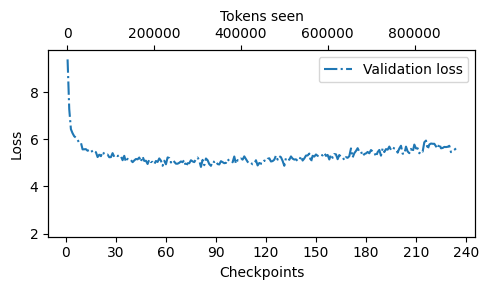

In [47]:
if __name__ == "__main__":
    tokenizer = BPETokenizer()
    sample_data = load_sample_data()
    full = "<|endoftext|>".join(sample_data[:200])
    split_idx = int(TRAIN_RATIO * len(full))

    train_data, val_data = full[:split_idx], full[split_idx:]
    train_loader = create_dataloader(
        train_data, tokenizer=tokenizer, batch_size=3, num_workers=2
    )
    val_loader = create_dataloader(
        val_data, tokenizer=tokenizer, batch_size=3, num_workers=2
    )
    print(f"Train loader - {len(train_loader)} batches:")
    print(f"Validation loader - {len(val_loader)} batches")

    model = GPTModel()
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
    num_epochs = 10
    plot_losses(
        num_epochs, *train_model(
            model=model,
            tokenizer=tokenizer,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            num_epochs=num_epochs,
            eval_freq=5,
            eval_iter=5,
            start_context="Every effort moves you",
        )
    )
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        MODEL_FILE,
    )